# Pretrained models

In [1]:
import json
import time
from io import BytesIO
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

PyTorch includes a number of pre-trained models in the `torchvision.models` module. These models are trained on the ImageNet dataset, which contains 1.4 million images and 1000 classes.

To initialize a pre-trained model, you need to first load the weights for the model, and then pass those weights to the model when you initialize it. For example, to load a pre-trained VGG16 model, you can do the following:

In [3]:
from torchvision.models import vgg16
from torchvision.models import VGG16_Weights

weights = VGG16_Weights.DEFAULT
model = vgg16(weights=weights)

model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

For more information on the available pre-trained models, see the [torchvision documentation](https://docs.pytorch.org/vision/0.26/models.html).

The pre-trained models in `torchvision` come with a set of pre-processing transforms that are designed to prepare the input images in the same way as the images that were used to train the model. You can access these transforms using the `transforms` method of the weights object. For example, to get the pre-processing transforms for the VGG16 model, you can do the following:

In [4]:
pre_trans = weights.transforms()
pre_trans

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

To help test our model, we can use random images from the [Picsum Photos](https://picsum.photos/) service, which provides random images of a specified size. 

In [5]:
def fetch_picsum_image(**kwargs) -> Image.Image:
    """
    Fetch an image from https://picsum.photos and return it as a PIL image.

    Kwargs:
        width (int): image width, default 200
        height (int): image height, default 300
        id (int | str): alias for image_id
        timeout (float | int): request timeout in seconds, default 10

    Returns:
        PIL.Image.Image
    """
    width = int(kwargs.get("width", 200))
    height = int(kwargs.get("height", 300))
    image_id = kwargs.get("id", None)
    timeout = float(kwargs.get("timeout", 10))

    if width <= 0 or height <= 0:
        raise ValueError("width and height must be positive integers")

    if image_id is not None:
        url = f"https://picsum.photos/id/{image_id}/{width}/{height}"
    else:
        # Random image endpoint; query param helps avoid cached repeats.
        url = f"https://picsum.photos/{width}/{height}?_={int(time.time() * 1000)}"

    req = Request(url, headers={"User-Agent": "python-picsum-client/1.0"})
    with urlopen(req, timeout=timeout) as resp:
        data = resp.read()

    return Image.open(BytesIO(data)).convert("RGB")

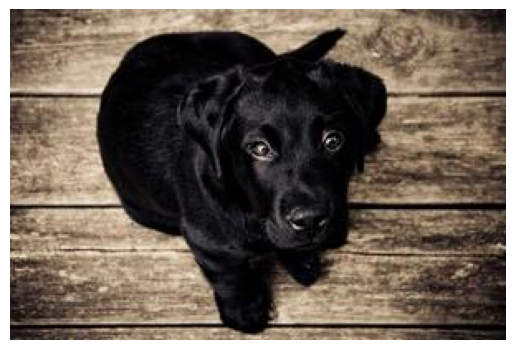

In [6]:
image = fetch_picsum_image(width=300, height=200, id=237)

plt.imshow(image)
plt.axis('off')
plt.show()

Before making predictions, let's pre-process the image using the pre-processing transforms that we got from the weights object.

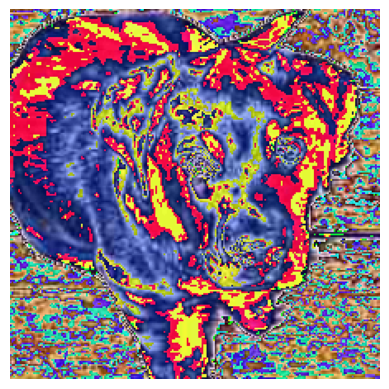

In [7]:
image_processed = pre_trans(image)

plt.imshow(F.to_pil_image(torch.squeeze(image_processed)))
plt.axis('off')
plt.show()

While it looks weird, this pre-processing actually helps the model make better predictions. The actual transformations applied by the pre-processing transforms are as follows:
- Resize the image to 256 pixels on the shorter side, while maintaining the aspect ratio.
- Center crop the image to 224x224 pixels. This is what changes the aspect ratio of the image, as well as zooming in to the center of the image.
- Normalize the pixel values using the mean and standard deviation of the ImageNet dataset. This is what causes the weird colors.

Using this pre-processing pipeline means that we can simply feed any arbitrary image into the model and it will work regardless of the original size or aspect ratio of the image.

In [8]:
imagenet_classes = json.load(open('./datasets/imagenet_class_index.json'))

def classify(_model, _preprocessing, _image, top_k=5):
    img_input = _preprocessing(_image).to(device)
    output = _model(img_input.unsqueeze(0))

    predictions = torch.topk(output[0], top_k)
    probs = nn.functional.softmax(output, dim=1)[0]

    res = [(idx, probs[idx]) for idx in predictions.indices.tolist()]

    return res

def index_to_label(index):
    return imagenet_classes[str(index)][1]

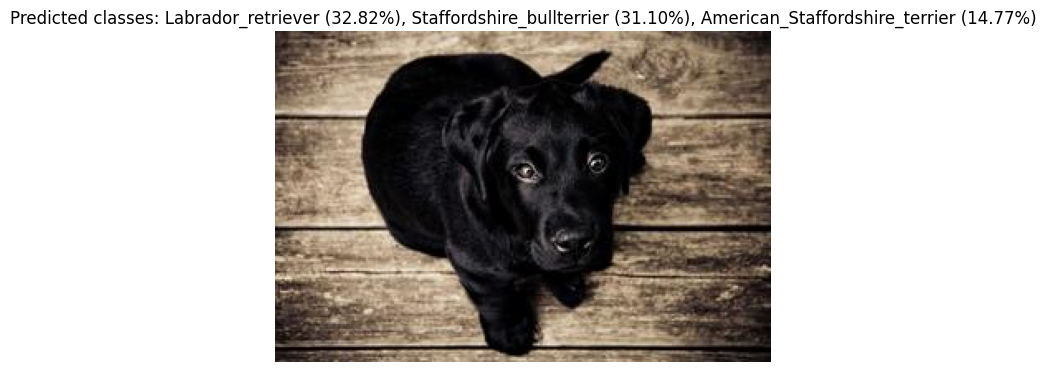

In [9]:
pred = classify(model, pre_trans, image, top_k=3)
plt.figure()
plt.axis('off')
plt.imshow(image)
_p = [f"{index_to_label(idx)} ({prob:.2%})" for idx, prob in pred]
plt.title(f"Predicted classes: {', '.join(_p)}")
plt.show()

We can also classify a batch of images at once, which is more efficient than classifying each image individually. To do this, we can stack the pre-processed images into a single tensor and pass that tensor through the model. The model will then return a batch of predictions, which we can process in the same way as we did for a single image.

In [10]:
def classify_batch(_model, _preprocessing, _images, top_k=5):
    img_inputs = torch.stack([_preprocessing(img) for img in _images]).to(device)
    outputs = _model(img_inputs)

    batch_predictions = torch.topk(outputs, top_k)

    batch_probs = nn.functional.softmax(outputs, dim=1)

    batch_res = []
    for i in range(len(_images)):
        res = [(idx, batch_probs[i][idx]) for idx in batch_predictions.indices[i].tolist()]
        batch_res.append(res)

    return batch_res

In [11]:
def download_random_images(n=5, width=300, height=200):
    images = []
    for _ in tqdm(range(n)):
        img = fetch_picsum_image(width=width,height=height)
        images.append(img)

    return images

In [12]:
batch = download_random_images(n=5, width=400, height=400)

100%|██████████| 5/5 [00:01<00:00,  2.89it/s]


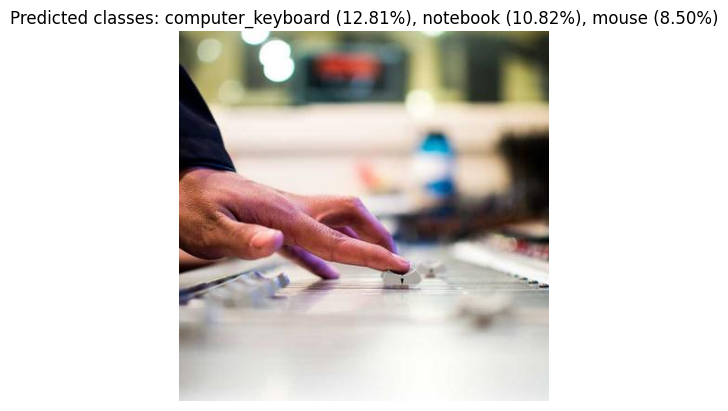

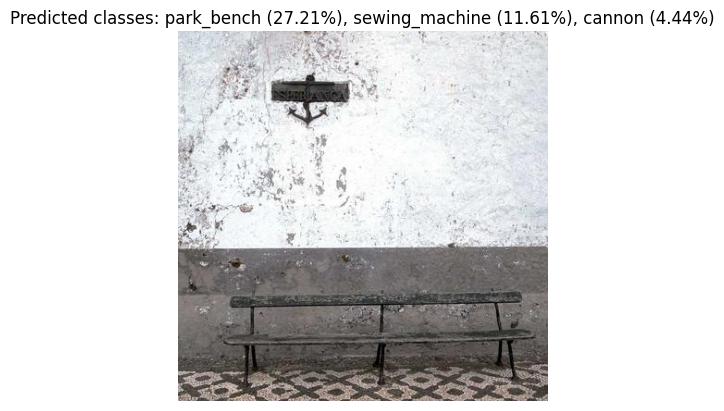

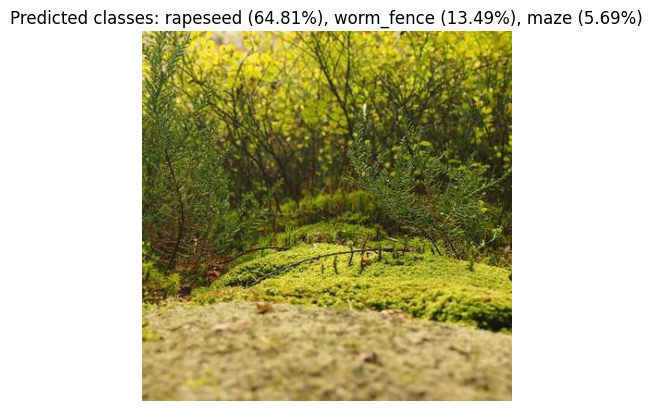

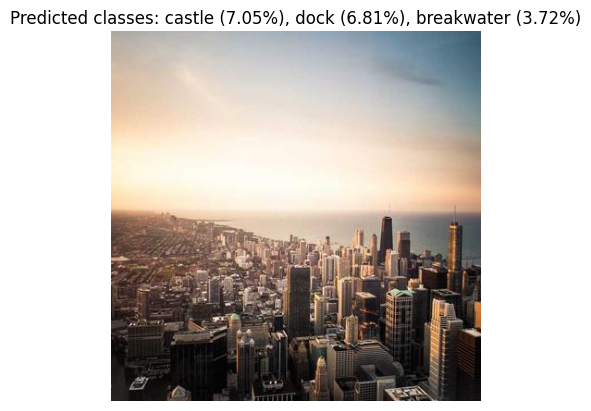

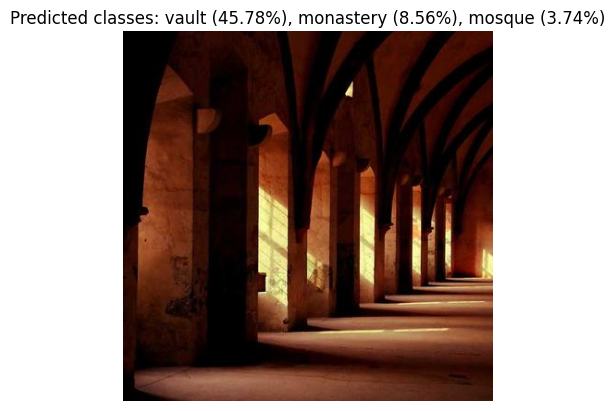

In [13]:
batch_preds = classify_batch(model, pre_trans, batch, top_k=3)

for i, preds in enumerate(batch_preds):
    plt.figure()
    plt.axis('off')
    plt.imshow(batch[i])
    idx, prob = preds[0]
    title = f"{index_to_label(idx)} ({prob:.2%})"
    _p = [f"{index_to_label(idx)} ({prob:.2%})" for idx, prob in preds]
    plt.title(f"Predicted classes: {', '.join(_p)}")

## Learning Exercise

### 1. Select some (at least 3) images from your photo library and classify them using this model.

If you don't have any image, feel free to search for images online. Just make sure to select the ones you want to try out instead of using random images.

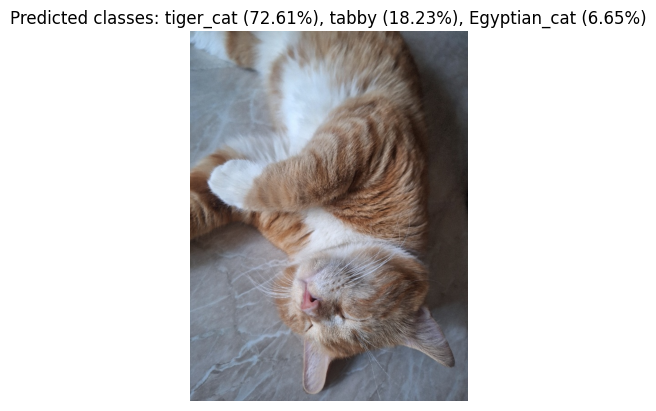

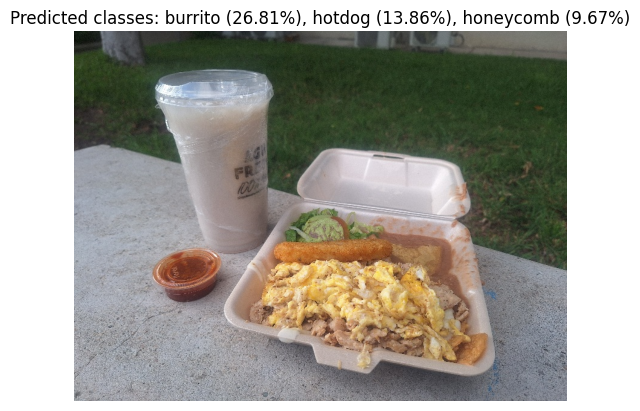

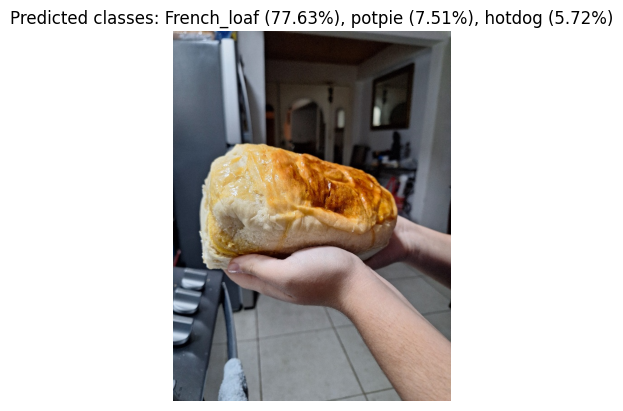

In [14]:
from PIL import Image
imagen_batch = [Image.open("./test_img/totito.jpg").convert("RGB"),Image.open("./test_img/comida.jpeg").convert("RGB"),Image.open("./test_img/pan.jpg").convert("RGB")]

batch_predicciones = classify_batch(model, pre_trans, imagen_batch, top_k=3)

for i, preds in enumerate(batch_predicciones):
    plt.figure()
    plt.axis('off')
    plt.imshow(imagen_batch[i])
    idx, prob = preds[0]
    title = f"{index_to_label(idx)} ({prob:.2%})"
    _p = [f"{index_to_label(idx)} ({prob:.2%})" for idx, prob in preds]
    plt.title(f"Predicted classes: {', '.join(_p)}")

### 2. Based on the results from images used in this notebook and the ones you provided, what are some strengths and weaknesses of the VGG16 pre-trained model?

El modelo, como primer debilidad, tiene que las clases en las que está entrenado son muy limitadas y, por lo que puedo notar, restringidas a esas del mundo angloparlante y, más específicamente, como de la cultura americana. Por eso es incapaz de notar que, bueno, un desayuno es un desayuno y, de hecho, aunque no le atinara qué desayuno es, la charola esta de plástico o poliestireno expandido lo delata, o sea, delata que no es un burrito, pienso yo. El gato, ay, no puedo creer que lo hayan clasificado así, como un gato tigre, pero bueno, es más comprensible, supongo. Lo que contrasta bastante con lo que nos platicaba el profesor en clase de que para los perros sí tienen de que sin fin de razas registradas en este modelo. Y para el pan, pues la verdad es que, aunque no es precisamente un French loaf, le atinó, o sea, es pan y creo que de entre todo eso es lo que mejor hizo. Sobre las imágenes, pues, bueno, vemos que tiene dificultades para tratar con imágenes del mundo moderno. Por ejemplo, el tablero de DJ y la ciudad, no la supo clasificar, pero está bien, supongo. y aun así, yo no lo consideraría mal modelo, nada más le agregaría más clases.

### 3. Find another pre-trained model and repeat this exercise using it instead of the VGG16 one. Does it perform better or worse?

In [15]:
from torchvision.models import wide_resnet101_2
from torchvision.models import Wide_ResNet101_2_Weights

wide_weights = Wide_ResNet101_2_Weights.DEFAULT
wide_model = wide_resnet101_2(weights=wide_weights)

wide_model.to(device)
wide_pre_trans = wide_weights.transforms()

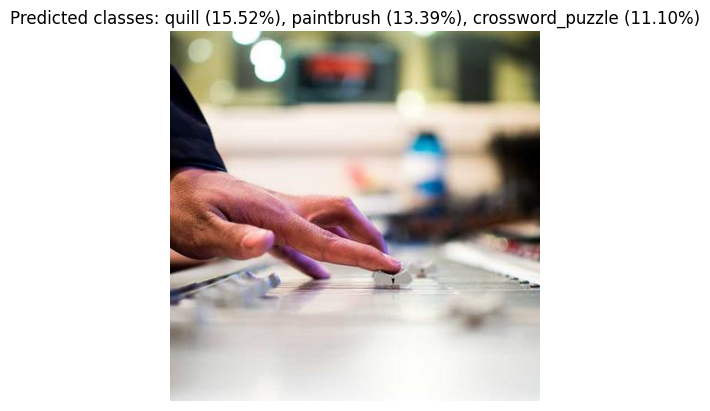

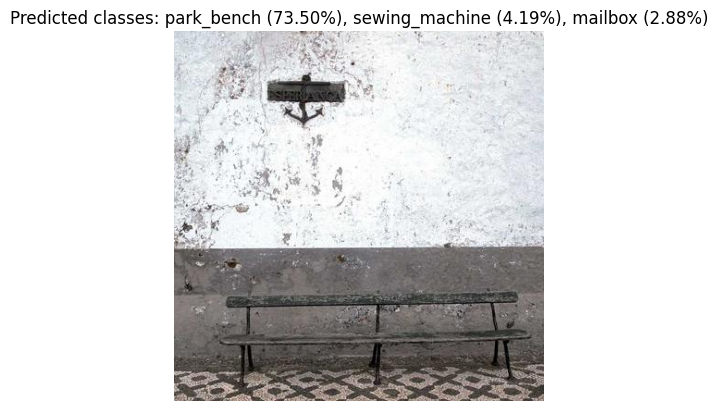

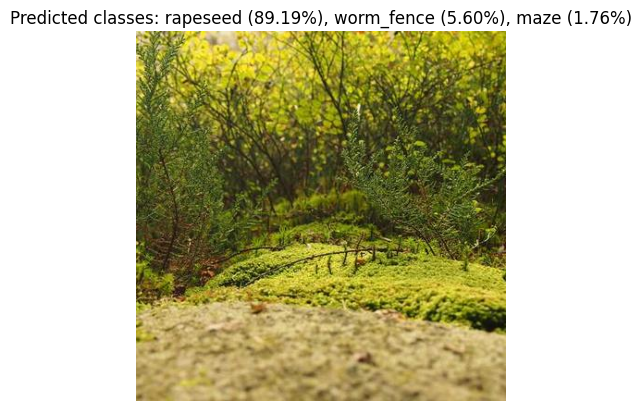

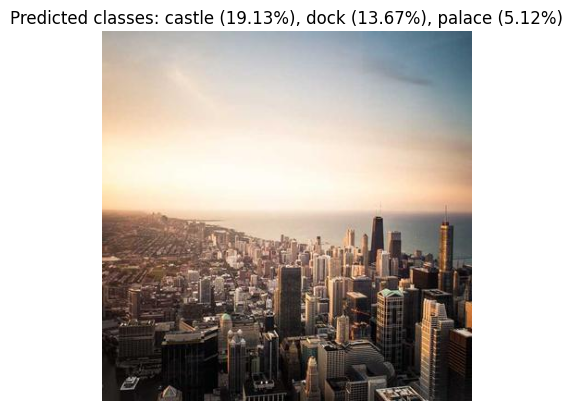

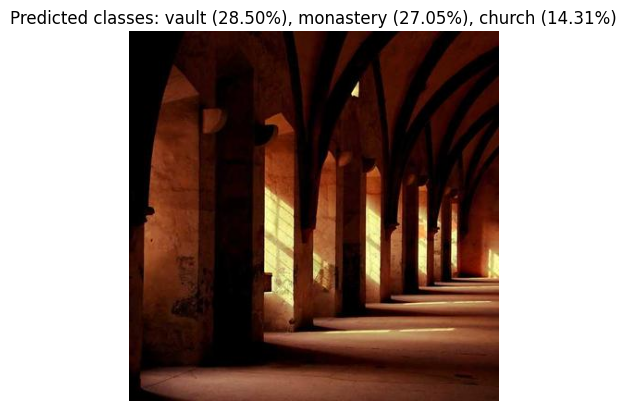

In [16]:
batch_preds = classify_batch(model, pre_trans, batch, top_k=3)

for i, preds in enumerate(batch_preds):
    plt.figure()
    plt.axis('off')
    plt.imshow(batch[i])
    idx, prob = preds[0]
    title = f"{index_to_label(idx)} ({prob:.2%})"
    _p = [f"{index_to_label(idx)} ({prob:.2%})" for idx, prob in preds]
    plt.title(f"Predicted classes: {', '.join(_p)}")

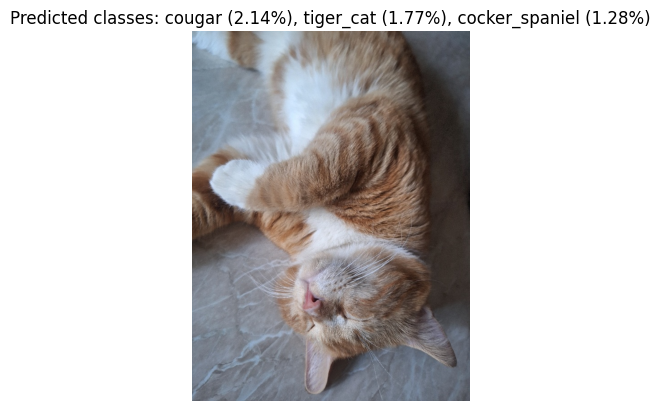

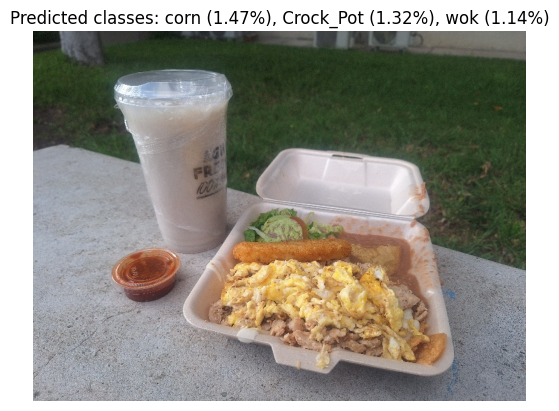

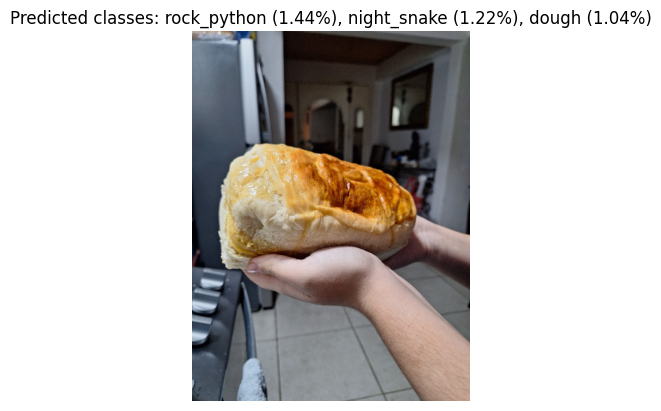

In [17]:
batch_predicciones = classify_batch(wide_model, wide_pre_trans, imagen_batch, top_k=3)

for i, preds in enumerate(batch_predicciones):
    plt.figure()
    plt.axis('off')
    plt.imshow(imagen_batch[i])
    idx, prob = preds[0]
    title = f"{index_to_label(idx)} ({prob:.2%})"
    _p = [f"{index_to_label(idx)} ({prob:.2%})" for idx, prob in preds]
    plt.title(f"Predicted classes: {', '.join(_p)}")

Para, en lo general, el modelo que seleccioné se comporta, diría, hasta peor por dos razones. Tiene las mismas predicciones en cuatro de las cinco imágenes utilizadas de internet. Para la primera de ellas, ni siquiera se acerca. O sea, la otra predicción, la que tenía el primer modelo, era razonable, un teclado, pero esto no, o sea, nada que ver. La quill, la paintbrush o el puzzle de crossword. En la predicción para el gato, pues era de la misma forma, supongo, porque no es un puma y lo clasifica como tal. pero tiene peor desempeño, supongo, porque al menos el primer modelo lo clasificaba como felino siempre, pero este también lo clasifica como quizá un perro. Luego, para el desayuno, lo clasifica como una mazorca, eso no tiene nada que ver, nada más el color. Luego, también apunta que quizás sea una... Olla con comida. Eso está un poco más razonable. Y... Y luego, pues, como un wok, eso también pues veo de dónde sí no estaría tan errado. De hecho, creo que en esa le atinó más este al tipo de alimento que el primer modelo, pero ahora para el pan lo clasificó como un pitón roca, una serpiente nocturna o una masa de pan. Sus primeras dos predicciones, pues, están mal y la que menos cree, la tercera, se acerca más, pero bueno, volvemos a lo mismo, entonces se desempeña mucho peor que el modelo que venía en este notebook por defecto. Entonces yo utilizaría VGG16 en lugar de este de WideResNet101.

### 4. Write your final conclussions

La mayor debilidad en los modelos masivos de reconocimiento de imágenes, creo que podemos estar de acuerdo que es la imposibilidad de tener clases infinitas, pero esto es un problema arquitectónico, pues, e inherente a querer hacer un proyecto todólogo. y es por lo que veo valor en que estos modelos preentrenados sugieran un dominio de los objetos y a partir de ahí poder tomar esas predicciones y entrenar un modelo más preciso para el dominio de aplicación del problema. Creo que eso sí es posible. Querer tener un modelo que clasifique cualquier tipo de objeto es inverosímil, porque el mundo tiene características eternamente infinitas y cada día se crean más cosas de muchos tipos, muchas variantes. Entonces, pienso que el valor que aportan estos modelos es eso que mencionaba antes, tener una noción, pero tunear finamente el resultado con un modelo específico al campo del problema.